In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, recall_score, roc_curve

# Загружаем подготовленные данные из предыдущего шага
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')

# Загружаем таргет. Метод .squeeze() превращает DataFrame (таблицу из 1 колонки) 
# в pandas.Series (вектор), что требуется для моделей sklearn.
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

print("Данные успешно загружены!")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

Данные успешно загружены!
X_train: (8000, 11), y_train: (8000,)


In [7]:
# Инициализируем модель. 
# ВАЖНО: class_weight='balanced' - это наш способ борьбы с дисбалансом. 
# Модель будет штрафовать себя в 4 раза сильнее за ошибку на ушедшем клиенте (т.к. их всего 20%).
log_reg = LogisticRegression(class_weight='balanced', random_state=42)

# Обучаем модель на тренировочной выборке
log_reg.fit(X_train, y_train)

print("Модель Logistic Regression успешно обучена!")

Модель Logistic Regression успешно обучена!


In [8]:
# Для метрик F1 и Recall нам нужны жесткие метки классов (0 или 1)
y_pred_lr = log_reg.predict(X_test)

# Для метрики ROC-AUC нужны вероятности принадлежности к классу 1 (ушедшие)
# predict_proba возвращает две колонки: вероятность 0 и вероятность 1. Берем вторую [:, 1].
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

# Считаем метрики
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
f1_lr = f1_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)

print("=== Результаты Baseline (Logistic Regression) ===")
print(f"ROC-AUC : {roc_auc_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")
print(f"Recall  : {recall_lr:.4f}")

=== Результаты Baseline (Logistic Regression) ===
ROC-AUC : 0.7771
F1-Score: 0.4987
Recall  : 0.7002


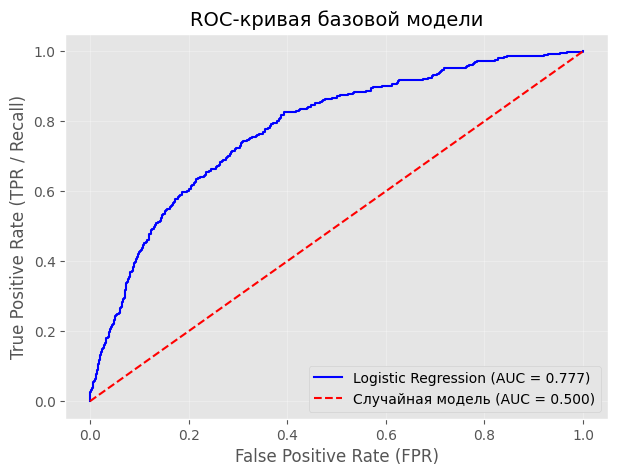

In [9]:
# Построим ROC-кривую, чтобы визуально оценить качество базовой модели
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Случайная модель (AUC = 0.500)')

plt.title('ROC-кривая базовой модели', fontsize=14)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()